# Legacy AMD Friday-to-Monday Exploration

I used this exploratory notebook to compare Friday closes with Monday opens and highs for AMD.


In [ ]:
# I resolve the repository root before running any project-relative paths.
from pathlib import Path
import os

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    # Path resolution still works before optional project dependencies are installed.
    def load_dotenv(*args, **kwargs):
        return False


def _find_project_root(start=None):
    location = Path(start or Path.cwd()).resolve()
    for candidate in (location, *location.parents):
        if (candidate / "config.yaml").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing config.yaml.")


PROJECT_ROOT = _find_project_root()
# The original notebooks were written from the repository root. Keeping that
# working directory preserves every existing data, output and model path.
os.chdir(PROJECT_ROOT)
load_dotenv(PROJECT_ROOT / "main.env")
print(f"Project root: {PROJECT_ROOT}")


In [1]:
# I import yfinance for the exploratory download
import yfinance as yf
import time
import datetime


In [2]:
# I download the latest six months of data for AMD stock
amd = yf.Ticker("AMD")
amd_data = amd.history(period="6mo")
# I filter the data for mondays and fridays only
amd_data = amd_data[amd_data.index.weekday.isin([0, 4])]
print(amd_data)

                                 Open        High         Low       Close  \
Date                                                                        
2025-09-29 00:00:00-04:00  160.119995  164.300003  159.899994  161.360001   
2025-10-03 00:00:00-04:00  170.679993  170.679993  163.139999  164.669998   
2025-10-06 00:00:00-04:00  226.449997  226.710007  203.009995  203.710007   
2025-10-10 00:00:00-04:00  232.770004  234.220001  213.199997  214.899994   
2025-10-13 00:00:00-04:00  220.199997  224.190002  214.899994  216.419998   
2025-10-17 00:00:00-04:00  233.259995  235.380005  227.910004  233.080002   
2025-10-20 00:00:00-04:00  236.470001  242.880005  234.399994  240.559998   
2025-10-24 00:00:00-04:00  243.360001  253.389999  241.949997  252.919998   
2025-10-27 00:00:00-04:00  257.880005  260.420013  249.800003  259.670013   
2025-10-31 00:00:00-04:00  259.600006  262.130005  253.410004  256.119995   
2025-11-03 00:00:00-05:00  259.329987  260.910004  253.889999  259.649994   

In [3]:
# I check whether friday close is always lower than monday close
amd_data['Close_diff'] = amd_data['Close'].diff()
amd_data['Close_diff'] = amd_data['Close_diff'].fillna(0)
amd_data['Close_diff'] = amd_data['Close_diff'].apply(lambda x: 'lower' if x < 0 else 'higher')
print(amd_data[['Close', 'Close_diff']])


                                Close Close_diff
Date                                            
2025-09-29 00:00:00-04:00  161.360001     higher
2025-10-03 00:00:00-04:00  164.669998     higher
2025-10-06 00:00:00-04:00  203.710007     higher
2025-10-10 00:00:00-04:00  214.899994     higher
2025-10-13 00:00:00-04:00  216.419998     higher
2025-10-17 00:00:00-04:00  233.080002     higher
2025-10-20 00:00:00-04:00  240.559998     higher
2025-10-24 00:00:00-04:00  252.919998     higher
2025-10-27 00:00:00-04:00  259.670013     higher
2025-10-31 00:00:00-04:00  256.119995      lower
2025-11-03 00:00:00-05:00  259.649994     higher
2025-11-07 00:00:00-05:00  233.539993      lower
2025-11-10 00:00:00-05:00  243.979996     higher
2025-11-14 00:00:00-05:00  246.809998     higher
2025-11-17 00:00:00-05:00  240.520004      lower
2025-11-21 00:00:00-05:00  203.779999      lower
2025-11-24 00:00:00-05:00  215.050003     higher
2025-11-28 00:00:00-05:00  217.529999     higher
2025-12-01 00:00:00-

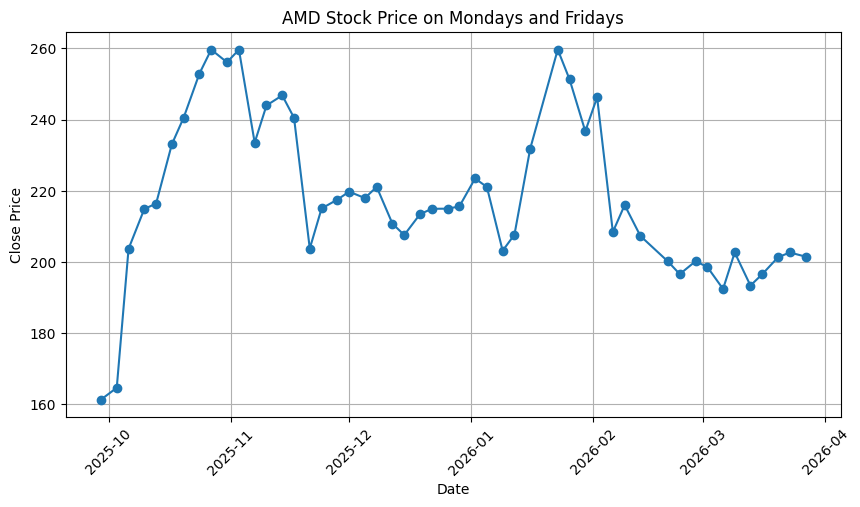

In [4]:
# I display it in a graph using matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(amd_data.index, amd_data['Close'], marker='o')
plt.title('AMD Stock Price on Mondays and Fridays')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
plt.grid()
plt.show()  

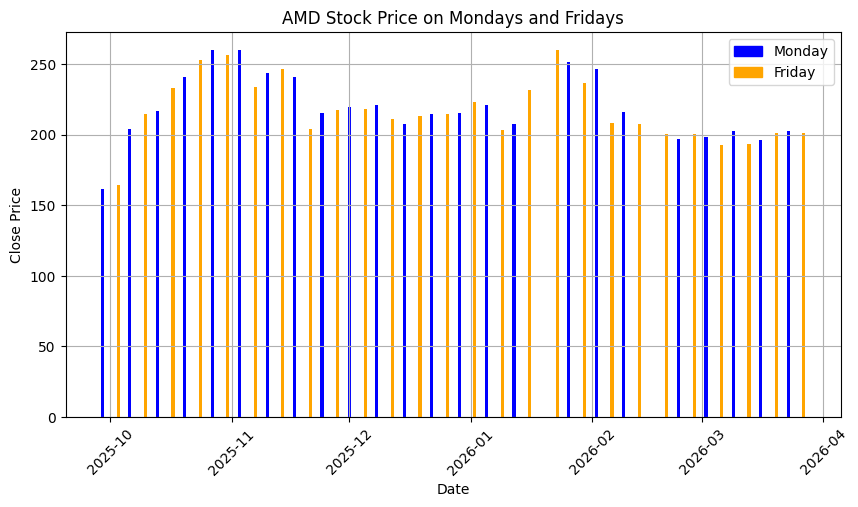

In [5]:
# I display a bar graph with different colors for mondays and fridays
import matplotlib.patches as mpatches
amd_data['Day'] = amd_data.index.weekday
amd_data['Color'] = amd_data['Day'].apply(lambda x: 'blue' if x == 0 else 'orange')
plt.figure(figsize=(10, 5))
plt.bar(amd_data.index, amd_data['Close'], color=amd_data['Color'])
plt.title('AMD Stock Price on Mondays and Fridays')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
blue_patch = mpatches.Patch(color='blue', label='Monday')
orange_patch = mpatches.Patch(color='orange', label='Friday')
plt.legend(handles=[blue_patch, orange_patch])
plt.grid()
plt.show()

In [6]:
# I count how many times is friday close lower than monday close
friday_lower_count = (amd_data['Close_diff'] == 'lower').sum()
print(f"Friday close is lower than Monday close {friday_lower_count} times in the last 6 months.")
#out of how many friday close data points
total_friday_count = (amd_data['Day'] == 4).sum()
print(f"Total Friday close data points: {total_friday_count}")


Friday close is lower than Monday close 19 times in the last 6 months.
Total Friday close data points: 26


In [7]:
#monday high - friday low
amd_data['High_diff'] = amd_data['High'].diff()
amd_data['High_diff'] = amd_data['High_diff'].fillna(0)
amd_data['High_diff'] = amd_data['High_diff'].apply(lambda x: 'lower' if x < 0 else 'higher')
print(amd_data[['High', 'High_diff']])


                                 High High_diff
Date                                           
2025-09-29 00:00:00-04:00  164.300003    higher
2025-10-03 00:00:00-04:00  170.679993    higher
2025-10-06 00:00:00-04:00  226.710007    higher
2025-10-10 00:00:00-04:00  234.220001    higher
2025-10-13 00:00:00-04:00  224.190002     lower
2025-10-17 00:00:00-04:00  235.380005    higher
2025-10-20 00:00:00-04:00  242.880005    higher
2025-10-24 00:00:00-04:00  253.389999    higher
2025-10-27 00:00:00-04:00  260.420013    higher
2025-10-31 00:00:00-04:00  262.130005    higher
2025-11-03 00:00:00-05:00  260.910004     lower
2025-11-07 00:00:00-05:00  235.869995     lower
2025-11-10 00:00:00-05:00  248.899994    higher
2025-11-14 00:00:00-05:00  253.440002    higher
2025-11-17 00:00:00-05:00  248.770004     lower
2025-11-21 00:00:00-05:00  208.830002     lower
2025-11-24 00:00:00-05:00  217.130005    higher
2025-11-28 00:00:00-05:00  218.300003    higher
2025-12-01 00:00:00-05:00  220.979996   

In [8]:
#check monday high against friday close 
amd_data['High_Close_diff'] = amd_data['High'] - amd_data['Close']
amd_data['High_Close_diff'] = amd_data['High_Close_diff'].apply(lambda x: 'lower' if x < 0 else 'higher')
print(amd_data[['High', 'Close', 'High_Close_diff']])

                                 High       Close High_Close_diff
Date                                                             
2025-09-29 00:00:00-04:00  164.300003  161.360001          higher
2025-10-03 00:00:00-04:00  170.679993  164.669998          higher
2025-10-06 00:00:00-04:00  226.710007  203.710007          higher
2025-10-10 00:00:00-04:00  234.220001  214.899994          higher
2025-10-13 00:00:00-04:00  224.190002  216.419998          higher
2025-10-17 00:00:00-04:00  235.380005  233.080002          higher
2025-10-20 00:00:00-04:00  242.880005  240.559998          higher
2025-10-24 00:00:00-04:00  253.389999  252.919998          higher
2025-10-27 00:00:00-04:00  260.420013  259.670013          higher
2025-10-31 00:00:00-04:00  262.130005  256.119995          higher
2025-11-03 00:00:00-05:00  260.910004  259.649994          higher
2025-11-07 00:00:00-05:00  235.869995  233.539993          higher
2025-11-10 00:00:00-05:00  248.899994  243.979996          higher
2025-11-14

In [9]:
# I report how many higher days are there for monday high against friday close out of total friday data points 
higher_count = (amd_data['High_Close_diff'] == 'higher').sum()
print(f"Monday high is higher than Friday close {higher_count} times in the last 6 months.")



Monday high is higher than Friday close 50 times in the last 6 months.


In [10]:
# how many times is monday high higher than friday close out of total monday data points
total_monday_count = (amd_data['Day'] == 0).sum()
print(f"Total Monday data points: {total_monday_count}")
print(f"Monday high is higher than Friday close {higher_count} times out of {total_monday_count} Monday data points.")


Total Monday data points: 24
Monday high is higher than Friday close 50 times out of 24 Monday data points.


In [11]:
#avg difference between friday close and monday high
amd_data['Close_High_diff'] = amd_data['Close'] - amd_data['High']
avg_diff = amd_data['Close_High_diff'].mean()
print(f"Average difference between Friday close and Monday high: {avg_diff:.2f}")

Average difference between Friday close and Monday high: -4.76
